/opt/anaconda3/envs/bayes_ml/lib/python3.11/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/var/folders/bb/5yjzvr_10jq7kd546ghdx78w0000gn/T/ipykernel_92113/2245778918.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sensor', y='Correlation', data=corr_df, palette='viridis')


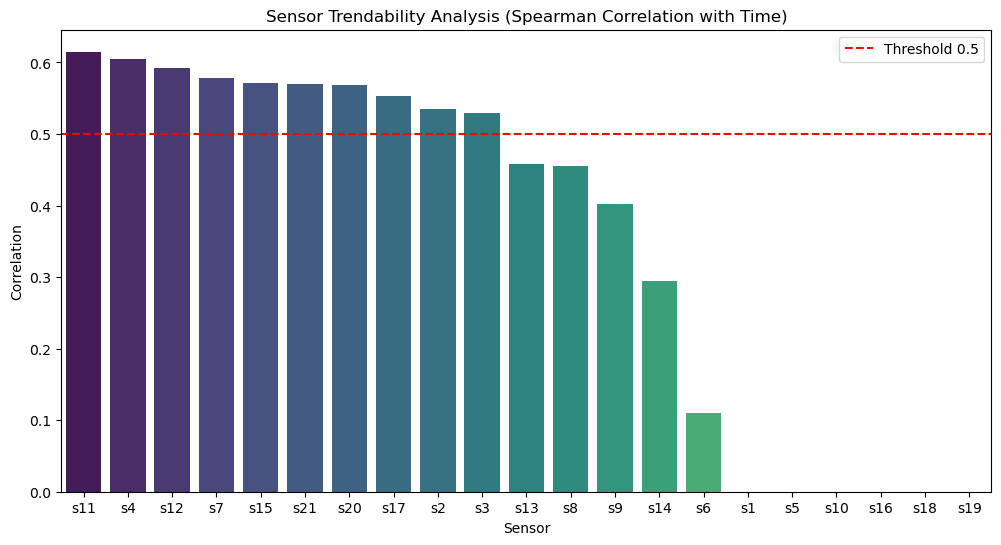

Top 10 Most Sensitive Sensors:
   Sensor  Correlation
10    s11     0.615044
3      s4     0.605036
11    s12     0.592811
6      s7     0.577702
14    s15     0.570805
20    s21     0.569532
19    s20     0.568259
16    s17     0.553136
1      s2     0.534384
2      s3     0.528700


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load Data
cols = ['unit', 'time', 'os1', 'os2', 'os3'] + [f's{i}' for i in range(1, 22)]
df = pd.read_csv('../data/train_FD001.txt', sep='\s+', header=None, names=cols)

# 2. Calculate the correlation between each sensor and "Time Cycles"
# We focus on the "absolute value" (identifying any significant change, whether it's an upward or downward trend)
correlations = []
sensors = [f's{i}' for i in range(1, 22)]

for s in sensors:
    # Spearman is used here because it is better than Pearson at capturing non-linear monotonic relationships
    corr = df[s].corr(df['time'], method='spearman')
    correlations.append(abs(corr))

# 3. Sort and Plot
corr_df = pd.DataFrame({'Sensor': sensors, 'Correlation': correlations})
corr_df = corr_df.sort_values(by='Correlation', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Sensor', y='Correlation', data=corr_df, palette='viridis')
plt.title('Sensor Trendability Analysis (Spearman Correlation with Time)')
plt.axhline(y=0.5, color='r', linestyle='--', label='Threshold 0.5') # Set a filtering threshold
plt.legend()
plt.show()

print("Top 10 Most Sensitive Sensors:")
print(corr_df.head(10))

Mean Lifetime: 206.31 cycles
Median Lifetime: 199.0 cycles
Minimum Lifetime: 128 cycles


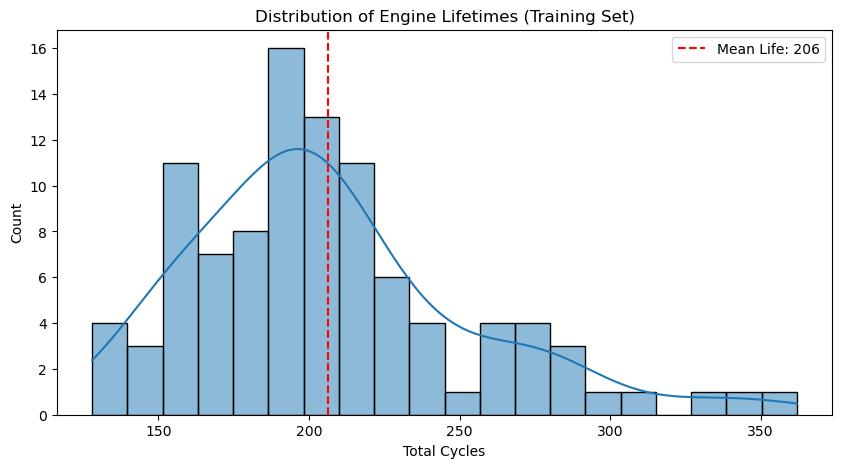

In [3]:
# 1. Calculate the maximum lifetime (Max Cycles) for each engine
max_life = df.groupby('unit')['time'].max()

# 2. Statistical Analysis
mean_life = max_life.mean()
median_life = max_life.median()
min_life = max_life.min()

print(f"Mean Lifetime: {mean_life:.2f} cycles")
print(f"Median Lifetime: {median_life} cycles")
print(f"Minimum Lifetime: {min_life} cycles")

# 3. Plot the lifetime distribution
plt.figure(figsize=(10, 5))
sns.histplot(max_life, kde=True, bins=20)
plt.axvline(x=mean_life, color='r', linestyle='--', label=f'Mean Life: {mean_life:.0f}')
plt.title('Distribution of Engine Lifetimes (Training Set)')
plt.xlabel('Total Cycles')
plt.legend()
plt.show()

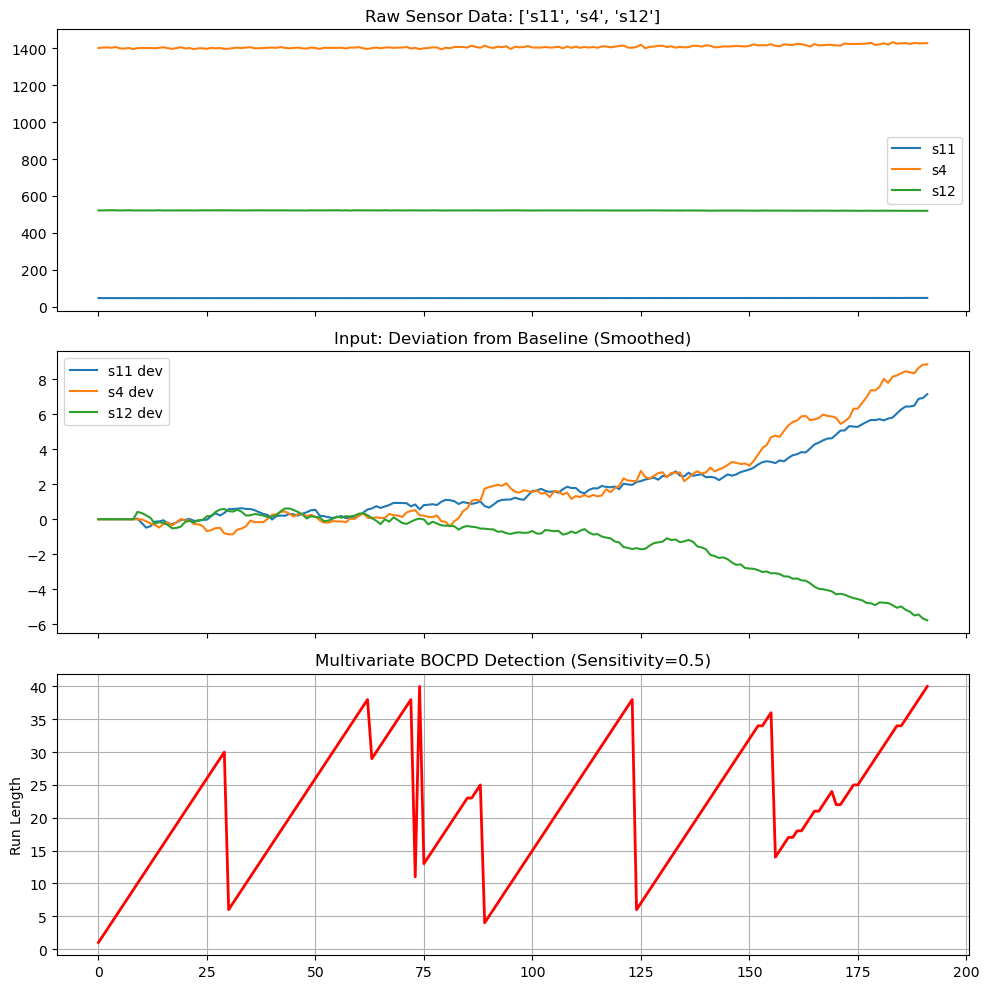

In [11]:
from scipy.stats import norm


unit_id = 1
# Choose your Top 3 Sensors
selected_sensors = ['s11', 's4', 's12'] 
raw_data = df[df['unit'] == unit_id][selected_sensors].values

# 【Preprocessing】
# 1. Standardize each sensor individually
# 2. Calculate Deviation from Baseline (using the first 20 cycles)
baseline_mean = np.mean(raw_data[:20], axis=0)
baseline_std = np.std(raw_data[:20], axis=0) + 1e-6

# residual_data shape: (Time, 3)
residual_data = (raw_data - baseline_mean) / baseline_std

# Smoothing (applied to each dimension separately)
smooth_residual = pd.DataFrame(residual_data).rolling(window=10).mean().fillna(0).values

# ==========================================
# 2. Multivariate BOCPD Class
# ==========================================
class MultivariateBOCPD:
    """
    Implements Bayesian Online Change Point Detection for multiple dimensions.
    Assumes dimensions are independent for joint probability calculation.
    """
    def __init__(self, hazard_rate=1/150, sensitivity=0.1, n_dim=3):
        self.hazard_rate = hazard_rate
        self.n_dim = n_dim
        
        # State Parameters:
        # For simplicity and robustness, we use a "Log-Probability Summation" strategy.
        # Each dimension maintains its own mu, kappa, alpha, and beta.
        
        # Initializing as (1, n_dim) arrays to facilitate parallel computation
        self.muT = np.zeros((1, n_dim))
        self.kappaT = np.ones((1, n_dim))
        self.alphaT = np.ones((1, n_dim))
        self.betaT = np.ones((1, n_dim)) * sensitivity
        
        self.R = np.array([1.0]) # Run Length Probability
        self.max_es = [] # MAP (Maximum A Posteriori) estimates

    def update(self, x):
        # x shape: (n_dim,) -> e.g., [s11_val, s4_val, s12_val]
        
        # 1. Calculate Predictive Probability for each dimension
        # Student-T Scale calculation
        scale = np.sqrt(self.betaT * (self.kappaT + 1) / (self.alphaT * self.kappaT))
        
        # We calculate probabilities; Gaussian is used here to approximate the Student-T distribution
        prob_dims = norm.pdf(x, loc=self.muT, scale=scale)
        
        # 【Key Step】 Multivariate Joint Probability
        # Assuming independence: P(x1, x2, x3) = P(x1) * P(x2) * P(x3)
        # Therefore, total_pred_prob is the product of the three individual probabilities.
        total_pred_prob = np.prod(prob_dims, axis=1)
        
        # Add a tiny constant to prevent zero probability (numerical stability)
        total_pred_prob = total_pred_prob + 1e-300
        
        # 2. Calculate Hazard
        H = self.hazard_rate
        growth_probs = total_pred_prob * self.R * (1 - H)
        cp_prob = np.sum(total_pred_prob * self.R * H)
        
        # 3. Update Run Length
        self.R = np.append(cp_prob, growth_probs)
        self.R = self.R / np.sum(self.R)
        
        # 4. Bayesian Parameter Update (Update each dimension independently)
        # Reshape x to (1, n_dim) for broadcast operations with (T, n_dim) parameters
        x_new = x.reshape(1, self.n_dim)
        
        new_muT = (self.kappaT * self.muT + x_new) / (self.kappaT + 1)
        new_kappaT = self.kappaT + 1
        new_alphaT = self.alphaT + 0.5
        new_betaT = self.betaT + (self.kappaT * (x_new - self.muT)**2) / (2 * (self.kappaT + 1))
        
        # Reset parameters for the "Change Point" (Run Length = 0) case
        mu0 = np.zeros((1, self.n_dim))
        kappa0 = np.ones((1, self.n_dim))
        alpha0 = np.ones((1, self.n_dim))
        beta0 = np.ones((1, self.n_dim)) * self.betaT[0, 0] # Maintain original sensitivity
        
        self.muT = np.concatenate((mu0, new_muT), axis=0)
        self.kappaT = np.concatenate((kappa0, new_kappaT), axis=0)
        self.alphaT = np.concatenate((alpha0, new_alphaT), axis=0)
        self.betaT = np.concatenate((beta0, new_betaT), axis=0)
        
        # (Optional) Pruning: Only keep paths with prob > 1e-4 to optimize speed
        
        self.max_es.append(np.argmax(self.R))

# ==========================================
# 3. Execution
# ==========================================
# Sensitivity can be slightly higher (e.g., 0.5) because multiplying 
# deviations from three dimensions significantly amplifies the signal.
mbocd = MultivariateBOCPD(hazard_rate=1/150, sensitivity=0.5, n_dim=3)
run_lengths = []

for x in smooth_residual:
    mbocd.update(x)
    run_lengths.append(mbocd.max_es[-1])

# ==========================================
# 4. Visualization
# ==========================================
fig, ax = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# Plot raw trends for the three sensors
for i, s_name in enumerate(selected_sensors):
    ax[0].plot(raw_data[:, i], label=s_name)
ax[0].set_title(f'Raw Sensor Data: {selected_sensors}')
ax[0].legend()

# Plot deviations (Inputs)
for i, s_name in enumerate(selected_sensors):
    ax[1].plot(smooth_residual[:, i], label=f'{s_name} dev')
ax[1].set_title('Input: Deviation from Baseline (Smoothed)')
ax[1].legend()

# Run Length Results
ax[2].plot(run_lengths, color='red', linewidth=2)
ax[2].set_title(f'Multivariate BOCPD Detection (Sensitivity=0.5)')
ax[2].set_ylabel('Run Length')
ax[2].grid(True)

plt.tight_layout()
plt.show()

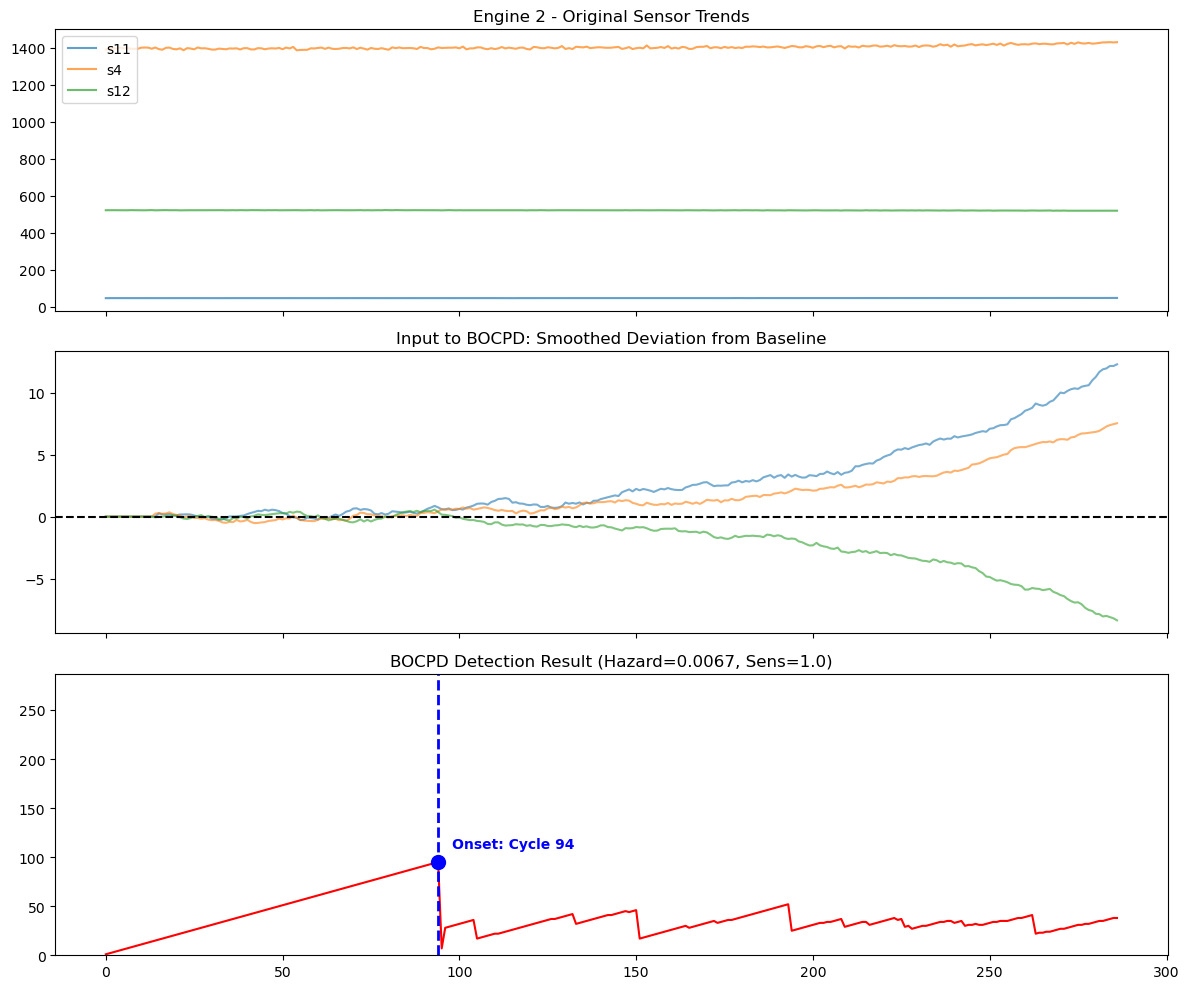

In [12]:
def bocpd_degradation_pipeline(df, unit_id=1, 
                               selected_sensors=['s11', 's4', 's12'],
                               baseline_range=(0, 20),
                               smooth_window=10,
                               hazard_rate=1/110,
                               sensitivity=7.5,
                               confidence_threshold=50,
                               ignore_start=30):
    """
    BOCPD Degradation Detection Pipeline
    
    Parameters:
    - baseline_range: Cycle interval used to calculate the health baseline (e.g., first 20 cycles).
    - smooth_window: Moving window size for signal smoothing.
    - hazard_rate: Prior probability of a change point occurring (1/Expected_Run_Length).
    - sensitivity: Sensitivity of the Bayesian model (beta0); smaller values are more sensitive.
    - confidence_threshold: Minimum Run Length height required to confirm an "Onset."
    - ignore_start: Number of initial cycles to force-ignore (to avoid startup noise).
    """
    
    # --- 1. Preprocessing ---
    engine_data = df[df['unit'] == unit_id][selected_sensors].values
    
    # Calculate Baseline (Health Reference)
    base_start, base_end = baseline_range
    mu_base = np.mean(engine_data[base_start:base_end], axis=0)
    std_base = np.std(engine_data[base_start:base_end], axis=0) + 1e-6
    
    # Calculate Residuals and apply smoothing
    residuals = (engine_data - mu_base) / std_base
    smooth_data = pd.DataFrame(residuals).rolling(window=smooth_window).mean().fillna(0).values
    
    # --- 2. Multivariate BOCPD Core Loop ---
    n_time, n_dim = smooth_data.shape
    
    # Initialize Hyperparameters (Normal-Gamma Prior)
    muT = np.zeros((1, n_dim))
    kappaT = np.ones((1, n_dim))
    alphaT = np.ones((1, n_dim))
    betaT = np.ones((1, n_dim)) * sensitivity
    
    R = np.array([1.0]) # Run Length Distribution
    run_lengths = []
    
    for t_step in range(n_time):
        x = smooth_data[t_step]
        
        # Calculate Predictive Probability
        scale = np.sqrt(betaT * (kappaT + 1) / (alphaT * kappaT))
        # Assuming independence across dimensions: probabilities are multiplied
        prob_dims = norm.pdf(x, loc=muT, scale=scale)
        total_pred_prob = np.prod(prob_dims, axis=1) + 1e-300
        
        # Calculate Growth and Reset Probabilities
        growth_probs = total_pred_prob * R * (1 - hazard_rate)
        cp_prob = np.sum(total_pred_prob * R * hazard_rate)
        
        # Update Run Length Distribution and Normalize
        R = np.append(cp_prob, growth_probs)
        R /= np.sum(R)
        
        # Update Bayesian Posterior Parameters
        x_new = x.reshape(1, n_dim)
        new_muT = (kappaT * muT + x_new) / (kappaT + 1)
        new_kappaT = kappaT + 1
        new_alphaT = alphaT + 0.5
        new_betaT = betaT + (kappaT * (x_new - muT)**2) / (2 * (kappaT + 1))
        
        # Prepare parameter matrices for the next step (including Reset initial values)
        muT = np.concatenate((np.zeros((1, n_dim)), new_muT), axis=0)
        kappaT = np.concatenate((np.ones((1, n_dim)), new_kappaT), axis=0)
        alphaT = np.concatenate((np.ones((1, n_dim)), new_alphaT), axis=0)
        betaT = np.concatenate((np.ones((1, n_dim)) * sensitivity, new_betaT), axis=0)
        
        run_lengths.append(np.argmax(R))
        
    # --- 3. Detection Logic ---
    rl_arr = np.array(run_lengths)
    # Detect where the Run Length drops (signifying a potential change point)
    drop_indices = np.where(rl_arr[:-1] > rl_arr[1:])[0]
    
    t_onset = None
    for idx in drop_indices:
        # Check if the drop occurs after the ignore period and meets the confidence height
        if idx > ignore_start and rl_arr[idx] > confidence_threshold:
            t_onset = idx
            break
            
    # --- 4. Visualization ---
    fig, ax = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    
    # Plot 1: Original Sensor Trends
    for i, s in enumerate(selected_sensors):
        ax[0].plot(engine_data[:, i], label=s, alpha=0.7)
    ax[0].set_title(f"Engine {unit_id} - Original Sensor Trends")
    ax[0].legend(loc='upper left')
    
    # Plot 2: Smoothed Deviation Signals (BOCPD Input)
    ax[1].plot(smooth_data, alpha=0.6)
    ax[1].axhline(y=0, color='black', linestyle='--')
    ax[1].set_title("Input to BOCPD: Smoothed Deviation from Baseline")
    
    # Plot 3: Run Length Results
    ax[2].plot(run_lengths, color='red', label='Run Length')
    if t_onset:
        ax[2].axvline(x=t_onset, color='blue', linestyle='--', linewidth=2)
        ax[2].scatter([t_onset], [run_lengths[t_onset]], color='blue', s=100, zorder=5)
        ax[2].annotate(f'Onset: Cycle {t_onset}', (t_onset, run_lengths[t_onset]), 
                        xytext=(10, 10), textcoords='offset points', color='blue', fontweight='bold')
    ax[2].set_title(f"BOCPD Detection Result (Hazard={hazard_rate:.4f}, Sens={sensitivity})")
    ax[2].set_ylim(0, n_time)
    
    plt.tight_layout()
    plt.show()
    
    return t_onset, run_lengths

# ==========================================
# Usage Example (Tune Parameters Here)
# ==========================================
# Assuming df has already been loaded
t_onset, rls = bocpd_degradation_pipeline(
    df, 
    unit_id=2,
    selected_sensors=['s11', 's4', 's12'], # Use the top 3 most correlated sensors
    baseline_range=(0, 30),         # Increased baseline range to avoid startup fluctuations
    smooth_window=15,               # Increased smoothing to filter out early noise
    hazard_rate=1/150,              # Lowered change expectation to give the model more "inertia"
    sensitivity=1.0,                # Increased beta0 to reduce sensitivity to minor noise
    confidence_threshold=60,        # Higher threshold to ensure the model builds enough confidence
    ignore_start=50                 # Force-ignore first 50 cycles to ensure stable operation
)

In [13]:
from tqdm import tqdm

# --- Modified Pipeline (Added show_plot control) ---
def bocpd_automated_logic(df, unit_id, 
                           selected_sensors=['s11', 's4', 's12'],
                           baseline_range=(0, 30),
                           smooth_window=15,
                           hazard_rate=1/110,
                           sensitivity=7.5,
                           confidence_threshold=80,
                           ignore_start=60,
                           show_plot=False):
    """
    Identical to previous logic, but added show_plot option for batch processing.
    """
    engine_data = df[df['unit'] == unit_id][selected_sensors].values
    mu_base = np.mean(engine_data[baseline_range[0]:baseline_range[1]], axis=0)
    std_base = np.std(engine_data[baseline_range[0]:baseline_range[1]], axis=0) + 1e-6
    residuals = (engine_data - mu_base) / std_base
    smooth_data = pd.DataFrame(residuals).rolling(window=smooth_window).mean().fillna(0).values
    
    n_time, n_dim = smooth_data.shape
    muT, kappaT, alphaT = np.zeros((1, n_dim)), np.ones((1, n_dim)), np.ones((1, n_dim))
    betaT = np.ones((1, n_dim)) * sensitivity
    R = np.array([1.0])
    run_lengths = []
    
    for t_step in range(n_time):
        x = smooth_data[t_step]
        scale = np.sqrt(betaT * (kappaT + 1) / (alphaT * kappaT))
        total_pred_prob = np.prod(norm.pdf(x, loc=muT, scale=scale), axis=1) + 1e-300
        growth_probs = total_pred_prob * R * (1 - hazard_rate)
        cp_prob = np.sum(total_pred_prob * R * hazard_rate)
        R = np.append(cp_prob, growth_probs)
        R /= np.sum(R)
        
        x_new = x.reshape(1, n_dim)
        new_muT = (kappaT * muT + x_new) / (kappaT + 1)
        new_kappaT, new_alphaT = kappaT + 1, alphaT + 0.5
        new_betaT = betaT + (kappaT * (x_new - muT)**2) / (2 * (kappaT + 1))
        
        muT = np.concatenate((np.zeros((1, n_dim)), new_muT), axis=0)
        kappaT = np.concatenate((np.ones((1, n_dim)), new_kappaT), axis=0)
        alphaT = np.concatenate((np.ones((1, n_dim)), new_alphaT), axis=0)
        betaT = np.concatenate((np.ones((1, n_dim)) * sensitivity, new_betaT), axis=0)
        run_lengths.append(np.argmax(R))
        
    # Detect Onset
    rl_arr = np.array(run_lengths)
    drop_indices = np.where(rl_arr[:-1] > rl_arr[1:])[0]
    t_onset = next((idx for idx in drop_indices if idx > ignore_start and rl_arr[idx] > confidence_threshold), None)
    
    return t_onset

# ==========================================
# Implement batch detection loop
# ==========================================

# 1. Get all unique Engine IDs (FD001 usually has 100)
unit_ids = df['unit'].unique()
results = []

print(f"Beginning FD001 dataset analysis, total of {len(unit_ids)} engines...")

# 2. Start loop
for uid in tqdm(unit_ids):
    # Use a set of parameters you tuned
    onset = bocpd_automated_logic(
        df, unit_id=uid,
        selected_sensors=['s11', 's4', 's12'],
        baseline_range=(0, 30),
        smooth_window=10,
        hazard_rate=1/100,
        sensitivity=7.5,
        confidence_threshold=60,
        ignore_start=50,
        show_plot=False # Close plots when batch processing
    )
    
    # 紀錄該引擎的總壽命
    total_cycles = len(df[df['unit'] == uid])
    
    results.append({
        'unit_id': uid,
        'total_cycles': total_cycles,
        't_onset': onset,
        'percent_healthy': (onset / total_cycles) * 100 if onset else None
    })

# 3. Convert to DataFrame and check results
onset_df = pd.DataFrame(results)

# Handle cases where Onset was not captured (Fallback to 125 empirical value)
onset_df['t_onset_final'] = onset_df['t_onset'].fillna(onset_df['total_cycles'] - 125)

print("\nDetection complete! Result summary:")
print(onset_df.head(10))

# 4. Statistical analysis: see when Onset commonly occurs
print(f"\nAverage degradation onset point: {onset_df['t_onset_final'].mean():.2f} cycles")
print(f"Proportion of engines with no points detected: {onset_df['t_onset'].isna().sum() / len(unit_ids) * 100:.1f}%")

# 5. Save results (this is your future label source)
# onset_df.to_csv('fd001_onsets.csv', index=False)

Beginning FD001 dataset analysis, total of 100 engines...


100%|██████████| 100/100 [00:00<00:00, 118.83it/s]


Detection complete! Result summary:
   unit_id  total_cycles  t_onset  percent_healthy  t_onset_final
0        1           192       91        47.395833             91
1        2           287      135        47.038328            135
2        3           179       96        53.631285             96
3        4           189      127        67.195767            127
4        5           269      119        44.237918            119
5        6           188      101        53.723404            101
6        7           259      124        47.876448            124
7        8           150       98        65.333333             98
8        9           201       76        37.810945             76
9       10           222      104        46.846847            104

Average degradation onset point: 112.38 cycles
Proportion of engines with no points detected: 0.0%


In [14]:
from tqdm import tqdm
import itertools

def full_grid_search_bocpd(df, sample_size=20):
    """
    Global Grid Search for the optimal BOCPD parameter combination.
    """
    # 1. Define parameter grid (Expand or shrink ranges based on needs)
    grid_params = {
        'baseline_end': [20, 30, 40],               # baseline_range is (0, end)
        'smooth_window': [10, 15, 20],              # Filtering strength
        'hazard_val': [90, 110, 130, 150],          # 1/hazard_rate
        'sensitivity': [5.0, 7.5, 10.0, 12.5],      # Passivity/Blunting level (Beta0)
        'conf_threshold': [60, 70, 80],             # Decision threshold
        'ignore_start': [40, 50, 60]                # Time to ignore initial noise
    }

    # Generate all possible combinations
    keys, values = zip(*grid_params.items())
    combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
    
    print(f"🚀 Testing a total of {len(combinations)} parameter combinations...")
    
    # Randomly sample engines to accelerate computation 
    # (20-30 units are usually representative of the population)
    sample_units = np.random.choice(df['unit'].unique(), sample_size, replace=False)
    
    results = []

    # 2. Begin Exhaustive Search
    for params in tqdm(combinations):
        current_onsets = []
        
        for uid in sample_units:
            # Call the BOCPD core logic (Assumes bocpd_automated_logic is defined)
            onset = bocpd_automated_logic(
                df, unit_id=uid,
                selected_sensors=['s11', 's4', 's12'],
                baseline_range=(0, params['baseline_end']),
                smooth_window=params['smooth_window'],
                hazard_rate=1 / params['hazard_val'],
                sensitivity=params['sensitivity'],
                confidence_threshold=params['conf_threshold'],
                ignore_start=params['ignore_start'],
                show_plot=False
            )
            
            if onset:
                total_life = len(df[df['unit'] == uid])
                # Calculate the ratio of the "Healthy Period" to Total Life
                current_onsets.append(onset / total_life)
        
        # 3. Scoring Logic
        # Require at least 70% detection rate across the sampled engines
        if len(current_onsets) > (sample_size * 0.7): 
            mean_h = np.mean(current_onsets)
            std_h = np.std(current_onsets)
            
            # Score Design: Healthy period ratio should align with FD001 norms (60%~75%),
            # and the standard deviation should be as small as possible (consistency).
            # We apply a penalty if the Mean Healthy ratio deviates from the 65% target.
            target_h = 0.65
            bias_penalty = abs(mean_h - target_h)
            score = (1 - std_h) - bias_penalty  # Higher is better
            
            # Store results for this combination
            res_entry = params.copy()
            res_entry['mean_healthy'] = mean_h
            res_entry['std_healthy'] = std_h
            res_entry['score'] = score
            results.append(res_entry)

    # Convert results to DataFrame for easier sorting
    results_df = pd.DataFrame(results).sort_values(by='score', ascending=False)
    return results_df

# ==========================================
# Optimization Execution
# ==========================================
# Recommendation: Start with sample_size=15 to verify logic before running full scale.
optimized_results = full_grid_search_bocpd(df, sample_size=20)

print("\n" + "="*50)
print("🏆 Top 5 best parameter combinations:")
print(optimized_results.head(5).to_string(index=False))
print("="*50)

🚀 Testing a total of 1296 parameter combinations...


100%|██████████| 1296/1296 [03:23<00:00,  6.36it/s]


🏆 Top 5 best parameter combinations:
 baseline_end  smooth_window  hazard_val  sensitivity  conf_threshold  ignore_start  mean_healthy  std_healthy    score
           40             20         150         12.5              80            60      0.649372     0.071607 0.927765
           40             20         150         12.5              70            50      0.649372     0.071607 0.927765
           40             20         150         12.5              60            40      0.649372     0.071607 0.927765
           40             20         150         12.5              60            60      0.649372     0.071607 0.927765
           40             20         150         12.5              70            40      0.649372     0.071607 0.927765


In [15]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import itertools
from scipy.stats import norm

def data_driven_grid_search(df, sample_size=20):
    """
    Purely data-driven optimizer: Focuses solely on population consistency (Minimum Variance).
    """
    # 1. Define parameter grid
    grid_params = {
        'baseline_end': [20, 30, 40],
        'smooth_window': [10, 15, 20],
        'hazard_val': [100, 110, 120],            # Locked within a reasonable range
        'sensitivity': [5.0, 7.5, 10.0, 12.5],
        'conf_threshold': [60, 70, 80],
        'ignore_start': [40, 50, 60]
    }

    keys, values = zip(*grid_params.items())
    combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
    
    print(f"📊 Performing data-driven optimization, testing {len(combinations)} combinations...")
    
    # Randomly select sample engines to represent the fleet
    sample_units = np.random.choice(df['unit'].unique(), sample_size, replace=False)
    results = []

    for params in tqdm(combinations):
        current_onsets = []
        for uid in sample_units:
            # Call BOCPD core logic
            onset = bocpd_automated_logic(
                df, unit_id=uid,
                selected_sensors=['s11', 's4', 's12'],
                baseline_range=(0, params['baseline_end']),
                smooth_window=params['smooth_window'],
                hazard_rate=1 / params['hazard_val'],
                sensitivity=params['sensitivity'],
                confidence_threshold=params['conf_threshold'],
                ignore_start=params['ignore_start'],
                show_plot=False
            )
            if onset:
                total_life = len(df[df['unit'] == uid])
                # Track the ratio of the healthy phase relative to total life
                current_onsets.append(onset / total_life)
        
        # 2. Modified scoring logic: Completely removed the 0.65 fixed penalty
        if len(current_onsets) > (sample_size * 0.8): # Coverage threshold (must detect at least 80% of units)
            mean_h = np.mean(current_onsets)
            std_h = np.std(current_onsets)
            
            # Score is based on consistency: the smaller the standard deviation, the higher the score.
            score = 1 / (std_h + 1e-6) 
            
            res = params.copy()
            res['mean_healthy'] = mean_h
            res['std_healthy'] = std_h
            res['score'] = score
            results.append(res)

    # 3. Occam's Razor Sorting
    # Hierarchy of priority: 
    # 1. Higher score (consistency) 
    # 2. Smaller window (lower detection latency) 
    # 3. Lower sensitivity value (more sensitive to change) 
    # 4. Shorter baseline range
    results_df = pd.DataFrame(results).sort_values(
        by=['score', 'smooth_window', 'sensitivity', 'baseline_end'], 
        ascending=[False, True, True, True]
    )
    
    return results_df

# ==========================================
# Execution
# ==========================================
optimized_results = data_driven_grid_search(df, sample_size=20)

print("\n" + "="*50)
print("🏆 Data-driven Optimization - Best Parameter Combinations (Filtered by Occam's Razor):")
print(optimized_results.head(10).to_string(index=False))
print("="*50)

📊 Performing data-driven optimization, testing 972 combinations...


100%|██████████| 972/972 [02:32<00:00,  6.36it/s]


🏆 Data-driven Optimization - Best Parameter Combinations (Filtered by Occam's Razor):
 baseline_end  smooth_window  hazard_val  sensitivity  conf_threshold  ignore_start  mean_healthy  std_healthy     score
           30             15         100          7.5              60            40      0.576741     0.071505 13.984923
           30             15         100          7.5              60            50      0.576741     0.071505 13.984923
           30             15         100          7.5              60            60      0.576741     0.071505 13.984923
           30             15         100          7.5              70            40      0.576741     0.071505 13.984923
           30             15         100          7.5              70            50      0.576741     0.071505 13.984923
           30             15         100          7.5              70            60      0.576741     0.071505 13.984923
           30             15         110          7.5             

In [17]:
# --- Modified Pipeline (Added show_plot control) ---
def bocpd_automated_logic(df, unit_id, 
                           selected_sensors=['s11', 's4', 's12'],
                           baseline_range=(0, 30),
                           smooth_window=15,
                           hazard_rate=1/100,
                           sensitivity=7.5,
                           confidence_threshold=60,
                           ignore_start=40,
                           show_plot=False):
    """
    Identical to previous logic, but added show_plot option for batch processing.
    """
    engine_data = df[df['unit'] == unit_id][selected_sensors].values
    mu_base = np.mean(engine_data[baseline_range[0]:baseline_range[1]], axis=0)
    std_base = np.std(engine_data[baseline_range[0]:baseline_range[1]], axis=0) + 1e-6
    residuals = (engine_data - mu_base) / std_base
    smooth_data = pd.DataFrame(residuals).rolling(window=smooth_window).mean().fillna(0).values
    
    n_time, n_dim = smooth_data.shape
    muT, kappaT, alphaT = np.zeros((1, n_dim)), np.ones((1, n_dim)), np.ones((1, n_dim))
    betaT = np.ones((1, n_dim)) * sensitivity
    R = np.array([1.0])
    run_lengths = []
    
    for t_step in range(n_time):
        x = smooth_data[t_step]
        scale = np.sqrt(betaT * (kappaT + 1) / (alphaT * kappaT))
        total_pred_prob = np.prod(norm.pdf(x, loc=muT, scale=scale), axis=1) + 1e-300
        growth_probs = total_pred_prob * R * (1 - hazard_rate)
        cp_prob = np.sum(total_pred_prob * R * hazard_rate)
        R = np.append(cp_prob, growth_probs)
        R /= np.sum(R)
        
        x_new = x.reshape(1, n_dim)
        new_muT = (kappaT * muT + x_new) / (kappaT + 1)
        new_kappaT, new_alphaT = kappaT + 1, alphaT + 0.5
        new_betaT = betaT + (kappaT * (x_new - muT)**2) / (2 * (kappaT + 1))
        
        muT = np.concatenate((np.zeros((1, n_dim)), new_muT), axis=0)
        kappaT = np.concatenate((np.ones((1, n_dim)), new_kappaT), axis=0)
        alphaT = np.concatenate((np.ones((1, n_dim)), new_alphaT), axis=0)
        betaT = np.concatenate((np.ones((1, n_dim)) * sensitivity, new_betaT), axis=0)
        run_lengths.append(np.argmax(R))
        
    # Detect Onset
    rl_arr = np.array(run_lengths)
    drop_indices = np.where(rl_arr[:-1] > rl_arr[1:])[0]
    t_onset = next((idx for idx in drop_indices if idx > ignore_start and rl_arr[idx] > confidence_threshold), None)
    
    return t_onset

# ==========================================
# Implement batch detection loop
# ==========================================

# 1. Get all unique Engine IDs (FD001 usually has 100)
unit_ids = df['unit'].unique()
results = []

print(f"Beginning FD001 dataset analysis, total of {len(unit_ids)} engines...")

# 2. Start loop
for uid in tqdm(unit_ids):
    # Use a set of parameters you tuned
    onset = bocpd_automated_logic(
        df, unit_id=uid,
        selected_sensors=['s11', 's4', 's12'],
        baseline_range=(0, 30),
        smooth_window=10,
        hazard_rate=1/100,
        sensitivity=7.5,
        confidence_threshold=60,
        ignore_start=50,
        show_plot=False # Close plots when batch processing
    )
    
    # 紀錄該引擎的總壽命
    total_cycles = len(df[df['unit'] == uid])
    
    results.append({
        'unit_id': uid,
        'total_cycles': total_cycles,
        't_onset': onset,
        'percent_healthy': (onset / total_cycles) * 100 if onset else None
    })

# 3. Convert to DataFrame and check results
onset_df = pd.DataFrame(results)

# Handle cases where Onset was not captured (Fallback to 125 empirical value)
onset_df['t_onset_final'] = onset_df['t_onset'].fillna(onset_df['total_cycles'] - 125)

print("\nDetection complete! Result summary:")
print(onset_df.head(10))

# 4. Statistical analysis: see when Onset commonly occurs
print(f"\nAverage degradation onset point: {onset_df['t_onset_final'].mean():.2f} cycles")
print(f"Proportion of engines with no points detected: {onset_df['t_onset'].isna().sum() / len(unit_ids) * 100:.1f}%")

# 5. Save results (this is your future label source)
# onset_df.to_csv('fd001_onsets.csv', index=False)

Beginning FD001 dataset analysis, total of 100 engines...


100%|██████████| 100/100 [00:00<00:00, 120.90it/s]


Detection complete! Result summary:
   unit_id  total_cycles  t_onset  percent_healthy  t_onset_final
0        1           192       91        47.395833             91
1        2           287      135        47.038328            135
2        3           179       96        53.631285             96
3        4           189      127        67.195767            127
4        5           269      119        44.237918            119
5        6           188      101        53.723404            101
6        7           259      124        47.876448            124
7        8           150       98        65.333333             98
8        9           201       76        37.810945             76
9       10           222      104        46.846847            104

Average degradation onset point: 112.38 cycles
Proportion of engines with no points detected: 0.0%
